1. Introduction

Capstone Project: Sports Betting and Machine Learning

Research Question
Can machine learning models estimate win probabilities and identify potential value betting opportunities using historical sports data?

Objective
This analysis applies logistic regression to predict game outcomes and compares predicted probabilities to market expectations derived from betting spreads.

2. Imports

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Visualization style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

print("Libraries imported and configuration set.")

Libraries imported and configuration set.


3. Load Data

In [70]:
# Cell 2: Load NFL datasets

games = pd.read_csv("../data/spreadspoke_scores.csv")
teams = pd.read_csv("../data/nfl_teams.csv")

# Check dataset shapes
print("Games dataset shape:", games.shape)
print("Teams dataset shape:", teams.shape)

# Preview samples
print("\nGames sample:")
print(games.head())

print("\nTeams sample:")
print(teams.head())

Games dataset shape: (14371, 17)
Teams dataset shape: (44, 8)

Games sample:
  schedule_date  schedule_season schedule_week  schedule_playoff  \
0      9/2/1966             1966             1             False   
1      9/3/1966             1966             1             False   
2      9/4/1966             1966             1             False   
3      9/9/1966             1966             2             False   
4     9/10/1966             1966             1             False   

            team_home  score_home  score_away        team_away  \
0      Miami Dolphins          14          23  Oakland Raiders   
1      Houston Oilers          45           7   Denver Broncos   
2  San Diego Chargers          27           7    Buffalo Bills   
3      Miami Dolphins          14          19    New York Jets   
4   Green Bay Packers          24           3  Baltimore Colts   

  team_favorite_id  spread_favorite over_under_line                   stadium  \
0              LVR            -14.0 

4. Data Cleaning

In [71]:
for col in ["spread_favorite", "over_under_line"]:
    games[col] = games[col].astype(str).str.strip()
    games[col] = games[col].replace("", np.nan)
    games[col] = pd.to_numeric(games[col], errors="coerce")

# Create target variable
games["home_win"] = (games["score_home"] > games["score_away"]).astype(int)

# Remove duplicates
games = games.drop_duplicates()

In [72]:
# Basic info
games.info()

# Summary statistics
display(games.describe(include="all"))

# Missing values
missing_summary = games.isnull().sum().sort_values(ascending=False)
display(missing_summary[missing_summary > 0])

# Duplicates
print("Duplicate rows:", games.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14371 entries, 0 to 14370
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   schedule_date        14371 non-null  object 
 1   schedule_season      14371 non-null  int64  
 2   schedule_week        14371 non-null  object 
 3   schedule_playoff     14371 non-null  bool   
 4   team_home            14371 non-null  object 
 5   score_home           14371 non-null  int64  
 6   score_away           14371 non-null  int64  
 7   team_away            14371 non-null  object 
 8   team_favorite_id     14366 non-null  object 
 9   spread_favorite      14366 non-null  float64
 10  over_under_line      11844 non-null  float64
 11  stadium              14371 non-null  object 
 12  stadium_neutral      14371 non-null  bool   
 13  weather_temperature  12861 non-null  float64
 14  weather_wind_mph     12844 non-null  float64
 15  weather_humidity     8717 non-null  

,schedule_date,schedule_season,schedule_week,schedule_playoff,team_home,score_home,score_away,team_away,team_favorite_id,spread_favorite,over_under_line,stadium,stadium_neutral,weather_temperature,weather_wind_mph,weather_humidity,weather_detail,home_win
count,14371,14371.000000,14371,14371,14371,14371.000000,14371.000000,14371,14366,14366.000000,11844.000000,14371,14371,12861.000000,12844.000000,8717.000000,3316,14371.000000
unique,2741,NaN,22,2,44,NaN,NaN,44,33,NaN,NaN,130,2,NaN,NaN,NaN,11,NaN
top,1/1/2017,NaN,2,False,San Francisco 49ers,NaN,NaN,Pittsburgh Steelers,DAL,NaN,NaN,Giants Stadium,False,NaN,NaN,NaN,indoor,NaN
freq,16,NaN,879,13772,505,NaN,NaN,495,666,NaN,NaN,531,14240,NaN,NaN,NaN,2968,NaN
mean,NaN,1997.743859,NaN,NaN,NaN,22.543038,19.881845,NaN,NaN,-5.767785,42.383629,NaN,NaN,59.021071,7.523746,67.036480,NaN,0.569759
std,NaN,16.993572,NaN,NaN,NaN,10.507446,10.142325,NaN,NaN,3.800451,4.801071,NaN,NaN,15.618880,5.733891,15.923443,NaN,0.495127
min,NaN,1966.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,-28.000000,28.000000,NaN,NaN,-9.000000,0.000000,4.000000,NaN,0.000000
25%,NaN,1984.000000,NaN,NaN,NaN,15.000000,13.000000,NaN,NaN,-7.500000,39.000000,NaN,NaN,48.000000,1.000000,57.000000,NaN,0.000000
50%,NaN,1999.000000,NaN,NaN,NaN,22.000000,20.000000,NaN,NaN,-5.000000,42.000000,NaN,NaN,62.000000,8.000000,69.000000,NaN,1.000000
75%,NaN,2012.000000,NaN,NaN,NaN,30.000000,27.000000,NaN,NaN,-3.000000,45.500000,NaN,NaN,72.000000,11.000000,79.000000,NaN,1.000000


weather_detail         11055
weather_humidity        5654
over_under_line         2527
weather_wind_mph        1527
weather_temperature     1510
spread_favorite            5
team_favorite_id           5
dtype: int64

Duplicate rows: 0


In [89]:
df = games.copy()
games.columns

Index(['schedule_date', 'schedule_season', 'schedule_week', 'schedule_playoff',
       'team_home', 'score_home', 'score_away', 'team_away',
       'team_favorite_id', 'spread_favorite', 'over_under_line', 'stadium',
       'stadium_neutral', 'weather_temperature', 'weather_wind_mph',
       'weather_humidity', 'weather_detail', 'home_win', 'point_diff',
       'total_points', 'favorite_is_home', 'spread_abs', 'spread_bin'],
      dtype='object')

5. Feature Engineering

In [90]:
games["point_diff"] = games["score_home"] - games["score_away"]
games["total_points"] = games["score_home"] + games["score_away"]
games["favorite_is_home"] = (games["spread_favorite"] < 0).astype(int)

In [91]:
games["home_win"] = (games["score_home"] > games["score_away"]).astype(int)

In [78]:
# Point differential
games["point_diff"] = games["score_home"] - games["score_away"]

# Absolute spread
games["spread_abs"] = games["spread_favorite"].abs()

# Total points
games["total_points"] = games["score_home"] + games["score_away"]

In [ ]:
6.  EDA (Visualizations)

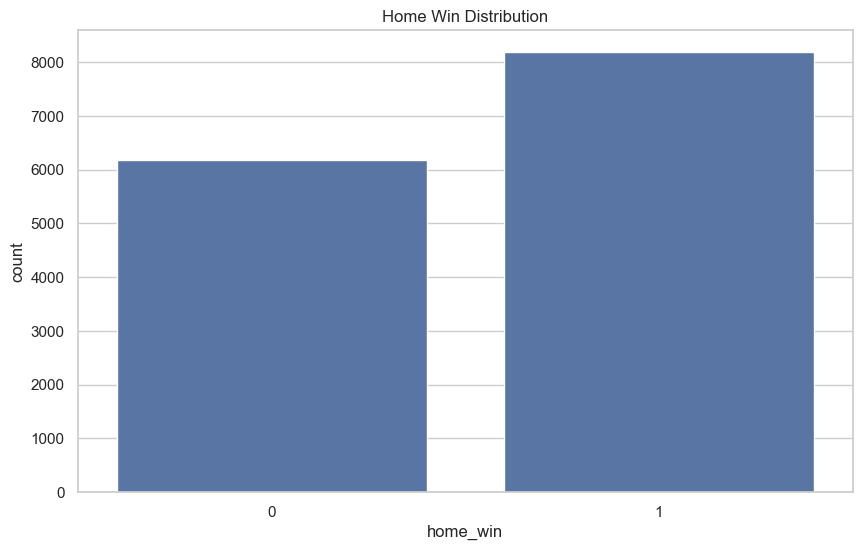

In [79]:
sns.countplot(x="home_win", data=games)
plt.title("Home Win Distribution")
plt.show()

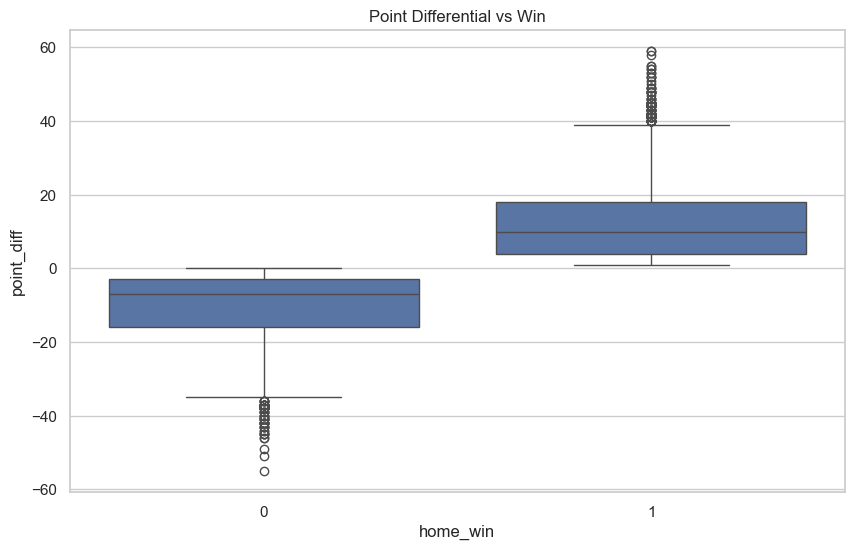

In [12]:
sns.boxplot(x="home_win", y="point_diff", data=games)
plt.title("Point Differential vs Win")
plt.show()

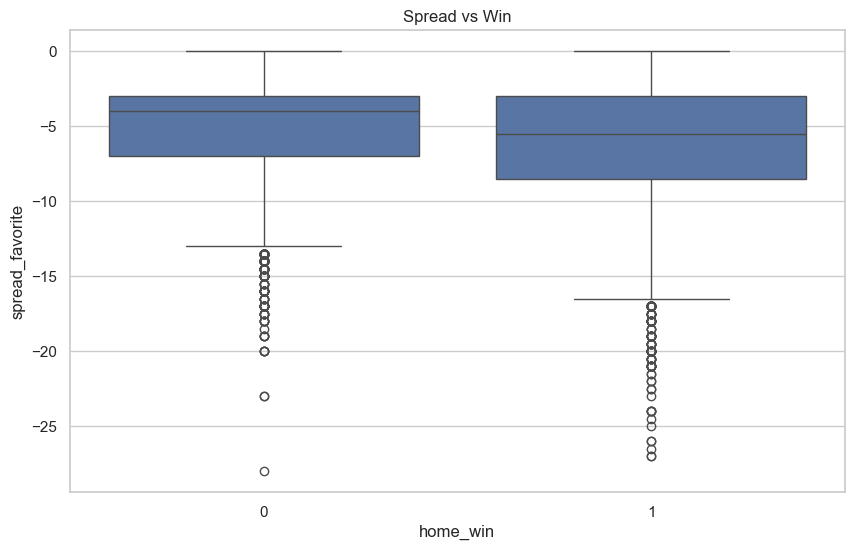

In [13]:
# Spread vs outcome
sns.boxplot(x="home_win", y="spread_favorite", data=games)
plt.title("Spread vs Win")
plt.show()

In [80]:
numeric_cols = ["score_home", "score_away", "spread_favorite", "point_diff"]

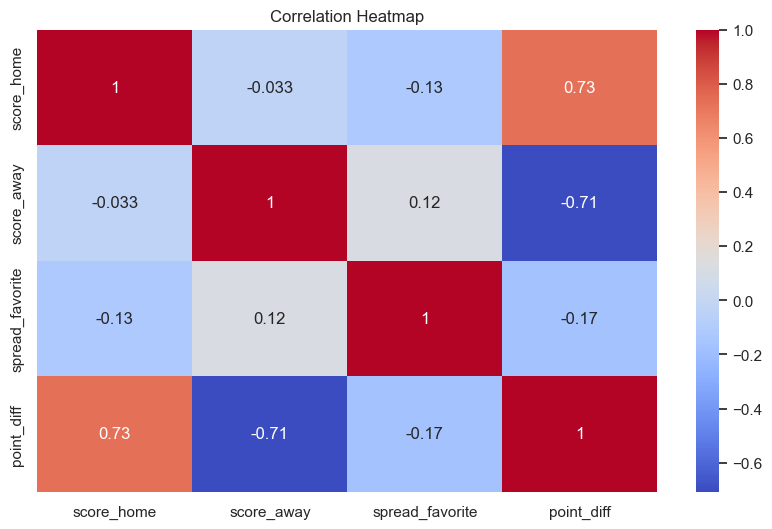

In [81]:
sns.heatmap(games[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [82]:
print(games[["spread_favorite", "over_under_line"]].head(10))
print(games[["spread_favorite", "over_under_line"]].dtypes)

   spread_favorite  over_under_line
0            -14.0              NaN
1             -7.0              NaN
2             -4.0              NaN
3            -16.0              NaN
4             -1.0              NaN
5             -3.0              NaN
6            -10.0              NaN
7            -10.0              NaN
8             -2.5              NaN
9             -7.0              NaN
spread_favorite    float64
over_under_line    float64
dtype: object


In [83]:
# Replace blank strings with NaN
games["spread_favorite"] = games["spread_favorite"].replace(" ", np.nan)
games["over_under_line"] = games["over_under_line"].replace(" ", np.nan)

# Convert to numeric
games["spread_favorite"] = pd.to_numeric(games["spread_favorite"], errors="coerce")
games["over_under_line"] = pd.to_numeric(games["over_under_line"], errors="coerce")

# Check results
print(games[["spread_favorite", "over_under_line"]].dtypes)
print(games[["spread_favorite", "over_under_line"]].isnull().sum())

spread_favorite    float64
over_under_line    float64
dtype: object
spread_favorite       5
over_under_line    2527
dtype: int64


7. Modeling

Accuracy: 0.5631067961165048


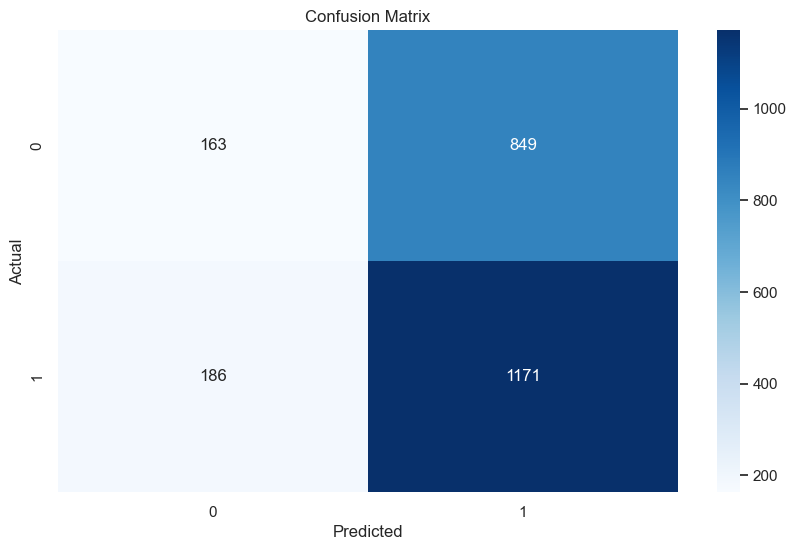

In [84]:
# Target
games["home_win"] = (games["score_home"] > games["score_away"]).astype(int)

# Features
features = ["spread_favorite", "over_under_line"]

# Keep only usable rows
model_df = games[features + ["home_win"]].dropna()

X = model_df[features]
y = model_df["home_win"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy: 0.5669058674546222


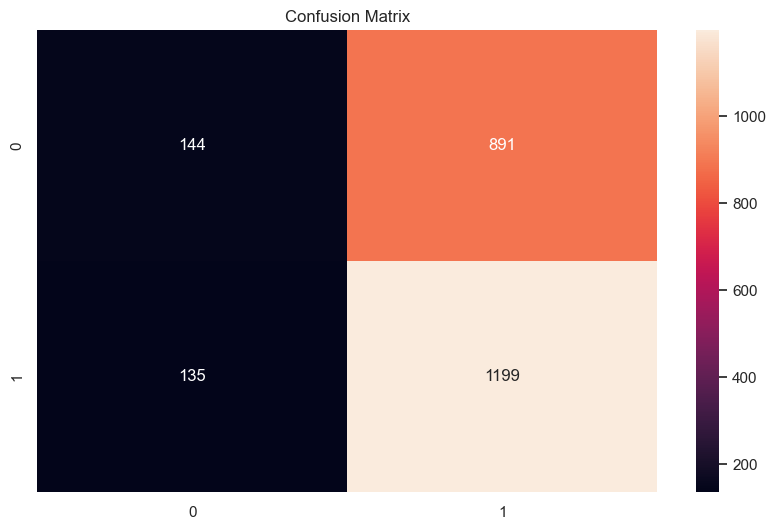

In [93]:

features = ["spread_favorite", "over_under_line"]

model_df = games[features + ["home_win"]].dropna()

X = model_df[features]
y = model_df["home_win"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

Model Evaluation

Logistic regression was selected because the target variable is binary (win/loss). 

Accuracy was used as a baseline evaluation metric because it measures the proportion of correct predictions. However, in sports betting applications, probability estimates are more important than classification accuracy because betting decisions depend on expected value rather than just predicting winners.

Therefore, predicted probabilities were compared against Vegas expectations to evaluate potential value betting opportunities.

8. Betting Logic

In [92]:
# Create Vegas proxy probability from spread
games["spread_bin"] = games["spread_favorite"].round(0)

spread_lookup = (
    games.groupby("spread_bin")["home_win"]
    .mean()
    .reset_index()
    .rename(columns={"home_win": "vegas_prob"})
)

# Build results
results = X_test.copy()
results["actual"] = y_test.values
results["model_prob"] = y_pred_proba
results["spread_bin"] = results["spread_favorite"].round(0)

results = results.merge(spread_lookup, on="spread_bin", how="left")

# Edge calculation
results["edge"] = results["model_prob"] - results["vegas_prob"]
results["value_signal"] = results["edge"] > 0

9. Betting Visualization

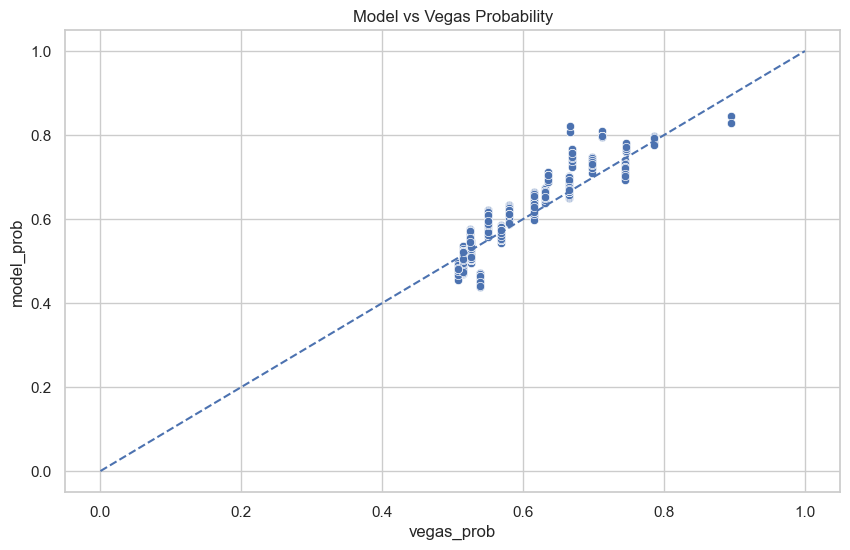

In [87]:
sns.scatterplot(x="vegas_prob", y="model_prob", data=results)
plt.plot([0,1],[0,1], linestyle="--")
plt.title("Model vs Vegas Probability")
plt.show()

10. Results Summary

Results

The logistic regression model achieved moderate predictive accuracy. Betting spread was a strong predictor of game outcomes.

By comparing model probabilities with Vegas expectations, the analysis identified situations where the model predicted higher win probabilities than the market.

These differences represent potential value betting opportunities, although results suggest that betting markets are relatively efficient overall.

Final Interpretation

The logistic regression model demonstrated that betting spread is one of the strongest predictors of game outcomes. The model produced probability estimates that were compared against market expectations derived from historical spread performance.

The comparison revealed that while the model occasionally identified positive edge situations, most predictions aligned closely with market probabilities. This suggests that sports betting markets are generally efficient.

However, the existence of small discrepancies indicates that machine learning models can still provide marginal advantages when identifying potential value bets.

Histogram

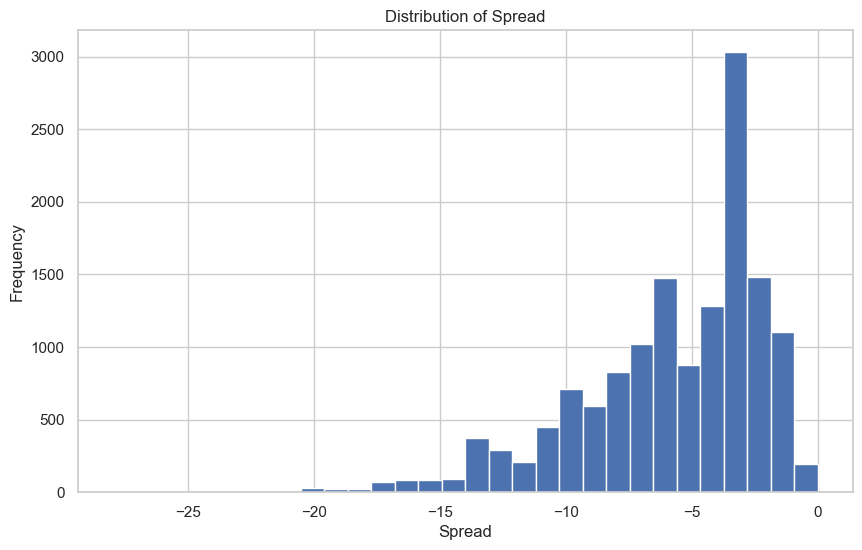

In [58]:
games["spread_favorite"].hist(bins=30)
plt.title("Distribution of Spread")
plt.xlabel("Spread")
plt.ylabel("Frequency")
plt.show()

Scatter

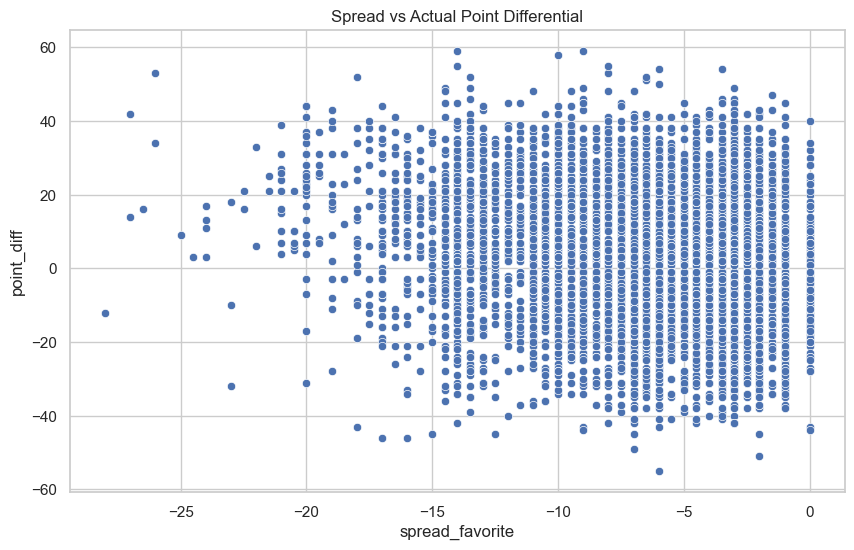

In [59]:
sns.scatterplot(x="spread_favorite", y="point_diff", data=games)
plt.title("Spread vs Actual Point Differential")
plt.show()

In [ ]:
Outlier Analysis

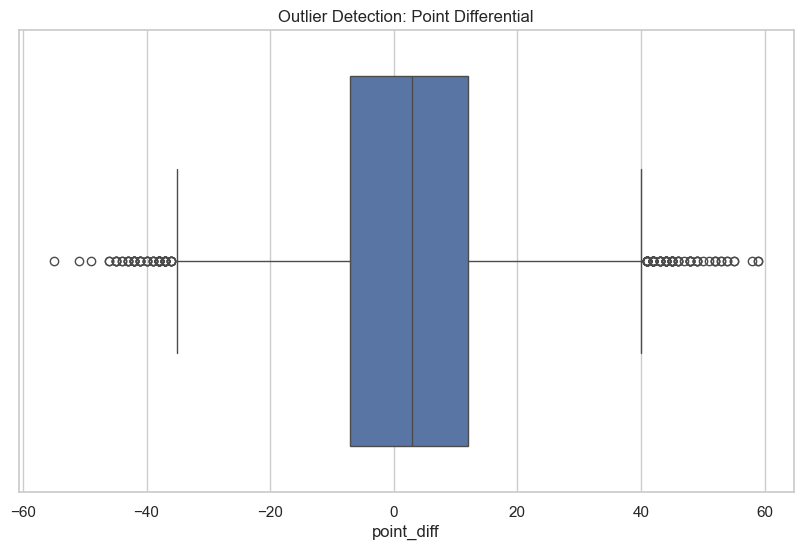

In [61]:
sns.boxplot(x=games["point_diff"])
plt.title("Outlier Detection: Point Differential")
plt.show()

Betting Insights

The model’s predicted probabilities were compared with Vegas expectations derived from historical spread outcomes.

The results show that in many cases, the model’s predictions align closely with the market, suggesting that sports betting markets are relatively efficient.

However, there are instances where the model predicts a higher probability of winning than the market. These differences represent potential value betting opportunities.

Overall, the findings suggest that while machine learning can identify patterns in historical data, the advantage over the betting market is likely small and requires careful analysis.

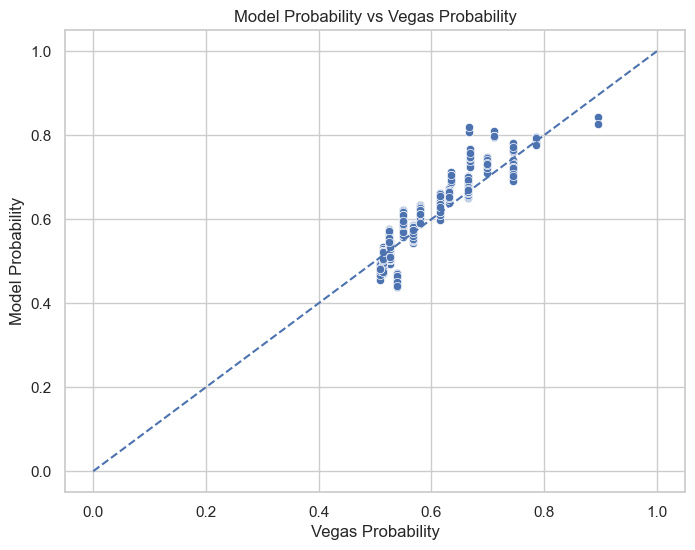

In [94]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="vegas_prob", y="model_prob", data=results)
plt.plot([0,1],[0,1], linestyle="--")
plt.title("Model Probability vs Vegas Probability")
plt.xlabel("Vegas Probability")
plt.ylabel("Model Probability")
plt.show()

Summary

In [95]:
print("Average Model Probability:", results["model_prob"].mean())
print("Average Vegas Probability:", results["vegas_prob"].mean())
print("Average Edge:", results["edge"].mean())
print("Number of Value Signals:", results["value_signal"].sum())

Average Model Probability: 0.5752760604535557
Average Vegas Probability: 0.5628552228166732
Average Edge: 0.012420837636882535
Number of Value Signals: 1606


Visualization

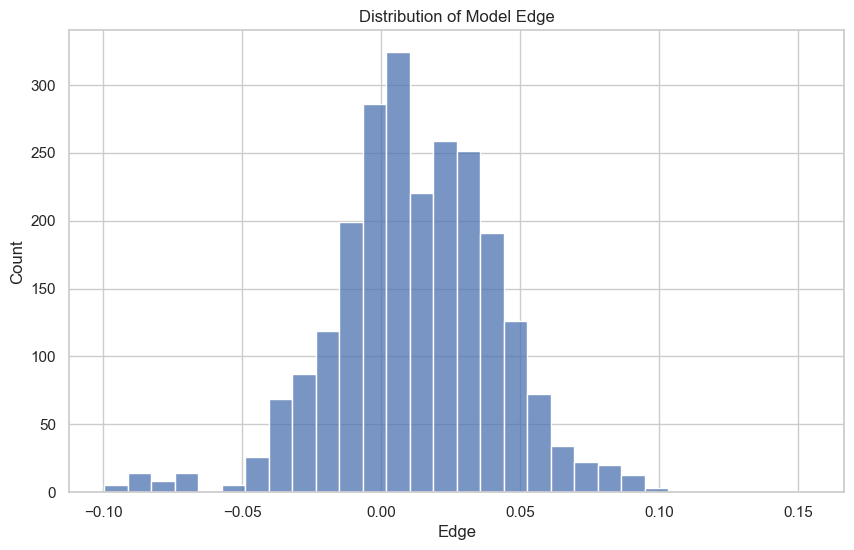

In [96]:
sns.histplot(results["edge"], bins=30)
plt.title("Distribution of Model Edge")
plt.xlabel("Edge")
plt.show()

README

# Sports Betting Capstone Project

## Overview
This project evaluates whether machine learning models can predict sports outcomes and identify value betting opportunities using historical NFL data.

## Methods
- Data cleaning and preprocessing
- Exploratory data analysis (EDA)
- Feature engineering
- Logistic regression modeling
- Comparison of predicted probabilities vs market expectations

## Results
The model achieved moderate predictive accuracy, with betting spread emerging as a strong predictor of outcomes.

Comparing model predictions with Vegas expectations revealed that most predictions align closely with the market, suggesting that betting markets are relatively efficient.

However, some discrepancies were identified, indicating potential value betting opportunities.

## Files
- capstone.ipynb